In [1]:
from pathlib import Path 
import os 
import sys
sys.path.insert(0, "../../../../../../shared_utils")
from experiment_utils import manual_filtering

import matplotlib.pyplot as plt 
import scanpy as sc
import numpy as np 
import pandas as pd
import scipy as sp 
import seaborn as sns
from tqdm import tqdm 
import copy
import math
import yaml
import fpsample

## Load solutions 

In [5]:
def load_pure_cell_type_solutions(
    path_to_results,
    paths,
    cell_types,
):

    path_to_results = Path(path_to_results)

    pure_cell_type_solution_dict = {
        cell_type: [] for cell_type in cell_types
    }

    for experiment_folder in tqdm(paths):

        cell_type_file_paths = path_to_results / experiment_folder

        if not cell_type_file_paths.exists():
            continue

        # Iterate through cell types
        for cell_type in os.listdir(cell_type_file_paths):

            if cell_type not in cell_types:
                continue

            config_exp_folders = cell_type_file_paths / cell_type

            if not config_exp_folders.is_dir():
                continue

            # Iterate through experiment configs
            for config_exp_folder in os.listdir(config_exp_folders):

                exp_folder = config_exp_folders / config_exp_folder

                if not exp_folder.is_dir():
                    continue

                # Check candidates.csv exists
                if "candidates.csv" not in os.listdir(exp_folder):
                    continue

                uncertainty_path = (
                    exp_folder
                    / "uncertainty_annotation"
                    / "candidates_with_uncertainties.csv"
                )

                # Check uncertainty annotation exists
                if uncertainty_path.exists():

                    candidate_with_uncertainty_df = pd.read_csv(
                        uncertainty_path
                    )

                    candidate_with_uncertainty_df["run_name"] = [
                        Path(file).name
                        for file in candidate_with_uncertainty_df[
                            "cfg:paths:dump_dir"
                        ]
                    ]

                    pure_cell_type_solution_dict[cell_type].append(
                        candidate_with_uncertainty_df
                    )

    return pure_cell_type_solution_dict

## Read annotation file

In [6]:
ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

ANNOTATION_CFG_FILE_BOUNDS = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/constraints/default_all_cols.yaml"
with open(ANNOTATION_CFG_FILE_BOUNDS, "r") as fb:
    annotation_cfg_bound = yaml.safe_load(fb)
ubound_dict, lbound_dict = annotation_cfg_bound["ubound_dict"],  annotation_cfg_bound["lbound_dict"]

# Collect per parameter bounds 
bounds = {}
for param in lbound_dict:
    bounds[param] = (lbound_dict[param], ubound_dict[param])

### Collect optimized samples 

In [11]:
path_to_results_post_loop2 = Path("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/bloodplus_inverse_fm_loop2")
paths_post_loop2 = os.listdir(path_to_results_post_loop2)

path_to_results_pre_loop2 = Path("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/bloodplus_inverse_fm_official")
paths_pre_loop2 = os.listdir(path_to_results_pre_loop2)

path_to_results_pre_loop1 = Path("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/bloodplus_inverse_fm_old_measurements_official")
paths_pre_loop1 = os.listdir(path_to_results_pre_loop1)

In [15]:
# cell_types = ["EryPro",
#               "late_MgkPro"]
cell_types = ["late_MgkPro"]

In [16]:
raw_solutions_post_loop2 = load_pure_cell_type_solutions(
    path_to_results_post_loop2,
    paths_post_loop2,
    cell_types,
)

raw_solutions_pre_loop2 = load_pure_cell_type_solutions(
    path_to_results_pre_loop2,
    paths_pre_loop2,
    cell_types,
)

raw_solutions_pre_loop1 = load_pure_cell_type_solutions(
    path_to_results_pre_loop1,
    paths_pre_loop1,
    cell_types,
)

100%|██████████| 6/6 [00:04<00:00,  1.35it/s]


In [17]:
raw_solutions_post_loop2 = {
    key: pd.concat(val, axis=0) for key, val in raw_solutions_post_loop2.items()
}

raw_solutions_pre_loop2 = {
    key: pd.concat(val, axis=0) for key, val in raw_solutions_pre_loop2.items()
}

raw_solutions_pre_loop1 = {
    key: pd.concat(val, axis=0) for key, val in raw_solutions_pre_loop1.items()
}

In [18]:
# erypro_df = pd.concat([raw_solutions_pre_loop2["EryPro"], 
#                       raw_solutions_post_loop2["EryPro"]], axis=0)

# erypro_df["dataset_type"] = ["Pre-loop2"] * len(raw_solutions_pre_loop2["EryPro"]) + ["Post-loop2"] * len(raw_solutions_post_loop2["EryPro"])  

In [23]:
mgkpro_df = pd.concat([raw_solutions_pre_loop1["late_MgkPro"],
                       raw_solutions_pre_loop2["late_MgkPro"], 
                      raw_solutions_post_loop2["late_MgkPro"]], axis=0)

mgkpro_df["dataset_type"] = ["Pre-loop1"] * len(raw_solutions_pre_loop1["late_MgkPro"]) \
                             + ["Pre-loop2"] * len(raw_solutions_pre_loop2["late_MgkPro"])  \
                             +  ["Post-loop2"] * len(raw_solutions_post_loop2["late_MgkPro"])  

In [25]:
# sns.histplot(erypro_df, x="target_ct_loss_std",  hue="dataset_type")

<Axes: xlabel='target_ct_loss_std', ylabel='Count'>

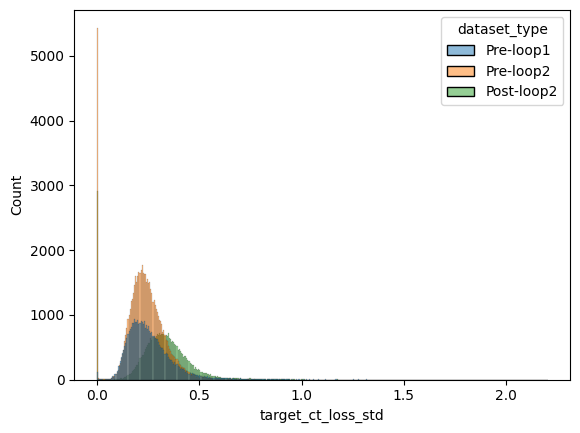

In [26]:
sns.histplot(mgkpro_df, x="target_ct_loss_std",  hue="dataset_type")

### Initialize targets

Only 4 types were optimized 

In [80]:
# Cell type fractions
celltype_fraction = {
    # "EryPro": 0.15,
                    "late_MgkPro": 0.10}

columns_of_interest = [
    'gm-csf_[ng_ml]',
    'tpo_[ng_ml]',
    'sr1_[nm]',
    'um171_[nm]',
    'um729_[µm]',
    'scf_[ng_ml]',
    'butyzamide_[nm]',
    'retinoic_acid_[µm]',
    'ldl_[ng_ml]',
    'il3_[ng_ml]',
    'o2_[%]',
    'days_of_culture',
    'run_name',
    "cfg:constraints:c_scheduler_kwargs:t_warmup",
    "cfg:constraints:c_scheduler_kwargs:vmin",
    "cfg:constraints:c_scheduler_kwargs:vmax",
    "loss", 
    "target_ct_loss_std",
    "target_ct_loss_mean",
    "ct_prop_total_variance",
    "dataset_type"
]

### Filter values

In [81]:
# # Collect filtered and annotated data frames 
# filtered_df_erypro, annotated_df_erypro = manual_filtering(
#     df_dict={"EryPro": erypro_df},
#     bounds=bounds,
#     columns_to_keep=columns_of_interest, 
#     celltype_fraction=celltype_fraction,
#     margin_frac_bounds=1, 
#     protocol_cols=protocol_cols
# )
# Collect filtered and annotated data frames 
filtered_df_mgkpro, annotated_df_mgkpro = manual_filtering(
    df_dict={"late_MgkPro": mgkpro_df},
    bounds=bounds,
    columns_to_keep=columns_of_interest, 
    celltype_fraction=celltype_fraction,
    margin_frac_bounds=1, 
    protocol_cols=protocol_cols
)

In [82]:
# # Filtered and unfiltered solutions 
# for ct in filtered_df_erypro:
#     print(f"Filtered {ct} number of solutions:", filtered_df_erypro[ct].shape[0])
#     print(f"Unfiltered {ct} number of solutions:", erypro_df.shape[0], "\n")

In [83]:
# Filtered and unfiltered solutions 
for ct in filtered_df_mgkpro:
    print(f"Filtered {ct} number of solutions:", filtered_df_mgkpro[ct].shape[0])
    print(f"Unfiltered {ct} number of solutions:", mgkpro_df.shape[0], "\n")

Filtered late_MgkPro number of solutions: 2480
Unfiltered late_MgkPro number of solutions: 133812 



In [84]:
# sns.histplot(filtered_df_erypro["EryPro"], x="target_ct_loss_std",  hue="dataset_type", kde=True)

In [85]:
# sns.histplot(
#     filtered_df_mgkpro["late_MgkPro"],
#     x="target_ct_loss_std",
#     hue="dataset_type",
#     stat="density",
#     kde=True,
#     bins=100
# )

In [86]:
# sns.histplot(filtered_df_erypro["EryPro"], x="EryPro_prop",  hue="dataset_type", kde=True, stat="probability")

/tmp/ipykernel_1184552/1665083419.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


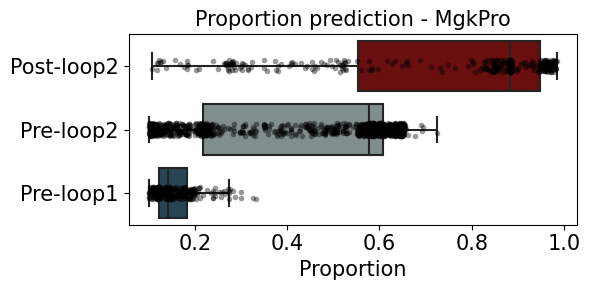

In [95]:
# Custom palette
palette = [
    "#780000",
    "#7F908F",
    "#20485B"
]

plt.figure(figsize=(6, 3))

ax = sns.boxplot(
    data=filtered_df_mgkpro["late_MgkPro"],
    x="late_MgkPro_prop",
    y="dataset_type",
    palette=palette,
    linewidth=1.5,
    fliersize=0,
)

# Overlay individual points
sns.stripplot(
    data=filtered_df_mgkpro["late_MgkPro"],
    x="late_MgkPro_prop",
    y="dataset_type",
    dodge=False,
    alpha=0.4,
    size=4,
    color="black",
    ax=ax
)

ax.set_title(
    "Proportion prediction - MgkPro",
    fontsize=15
)

ax.set_xlabel(
    "Proportion",
    fontsize=15
)

ax.set_ylabel(
    "",
    fontsize=15
)

# Increase tick label size
ax.tick_params(
    axis='both',
    labelsize=15
)

plt.tight_layout()
plt.savefig("proportion_performance.svg", format="svg", bbox_inches="tight")
plt.show()

/tmp/ipykernel_1184552/3692642531.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


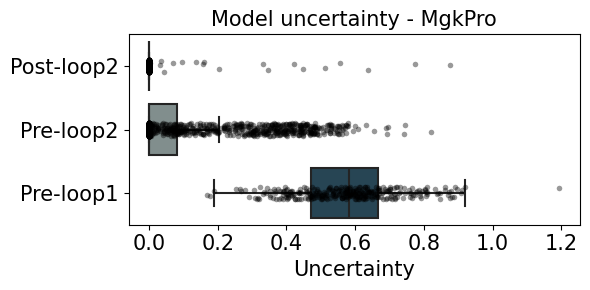

In [96]:
# Custom palette
palette = [
    "#780000",
    "#7F908F",
    "#20485B"
]

plt.figure(figsize=(6, 3))

ax = sns.boxplot(
    data=filtered_df_mgkpro["late_MgkPro"],
    x="target_ct_loss_std",
    y="dataset_type",
    palette=palette,
    linewidth=1.5,
    fliersize=0,
)

# Overlay individual points
sns.stripplot(
    data=filtered_df_mgkpro["late_MgkPro"],
    x="target_ct_loss_std",
    y="dataset_type",
    dodge=False,
    alpha=0.4,
    size=4,
    color="black",
    ax=ax
)

ax.set_title(
    "Model uncertainty - MgkPro",
    fontsize=15
)

ax.set_xlabel(
    "Uncertainty",
    fontsize=15
)

ax.set_ylabel(
    "",
    fontsize=15
)

ax.tick_params(
    axis='both',
    labelsize=15
)

plt.tight_layout()
plt.savefig("uncertainty_performance.svg", format="svg", bbox_inches="tight")
plt.show()